<a href="https://colab.research.google.com/github/nandamanohar/Supervised-Learning-PROJECT/blob/main/SupervisedLearning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
export=pd.read_csv('/content/export_orders.csv')
export.head()

,order_id,order_date,customer_id,country,product_category,quantity,unit_price,discount_pct,total_amount,shipping_mode,shipping_days,payment_terms,customer_rating,delayed,returned
0,EXP1001,2025-01-01,C160,UAE,Spices,301,17.97,5,5138.52,Sea,12.0,LC,5.0,0,0
1,EXP1002,2025-01-02,C132,Saudi Arabia,Coir Products,637,5.80,5,3509.87,Sea,17.0,Net30,5.0,0,0
2,EXP1003,2025-01-02,C087,USA,Textiles,896,12.20,0,10931.20,Sea,29.0,Advance,3.0,1,0
3,EXP1004,2025-01-02,C192,UAE,Tea,435,8.52,5,3520.89,Sea,17.0,Advance,3.0,0,0
4,EXP1005,2025-01-03,C227,UK,Tea,304,7.57,0,2301.28,Sea,29.0,LC,4.0,1,0


# Data Understanding

In [3]:
export.shape

(2000, 15)

In [4]:
export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2000 non-null   object 
 1   order_date        2000 non-null   object 
 2   customer_id       2000 non-null   object 
 3   country           2000 non-null   object 
 4   product_category  2000 non-null   object 
 5   quantity          2000 non-null   int64  
 6   unit_price        1971 non-null   float64
 7   discount_pct      2000 non-null   int64  
 8   total_amount      2000 non-null   float64
 9   shipping_mode     2000 non-null   object 
 10  shipping_days     1961 non-null   float64
 11  payment_terms     1971 non-null   object 
 12  customer_rating   1921 non-null   float64
 13  delayed           2000 non-null   int64  
 14  returned          2000 non-null   int64  
dtypes: float64(4), int64(4), object(7)
memory usage: 234.5+ KB


In [5]:
export['order_date']=pd.to_datetime(export['order_date'])

In [6]:
export['order_year'] = export['order_date'].dt.year
export['order_month'] = export['order_date'].dt.month
export['order_day'] = export['order_date'].dt.day

In [7]:
export.drop('order_date', axis=1, inplace=True)

In [8]:
export.head()

,order_id,customer_id,country,product_category,quantity,unit_price,discount_pct,total_amount,shipping_mode,shipping_days,payment_terms,customer_rating,delayed,returned,order_year,order_month,order_day
0,EXP1001,C160,UAE,Spices,301,17.97,5,5138.52,Sea,12.0,LC,5.0,0,0,2025,1,1
1,EXP1002,C132,Saudi Arabia,Coir Products,637,5.80,5,3509.87,Sea,17.0,Net30,5.0,0,0,2025,1,2
2,EXP1003,C087,USA,Textiles,896,12.20,0,10931.20,Sea,29.0,Advance,3.0,1,0,2025,1,2
3,EXP1004,C192,UAE,Tea,435,8.52,5,3520.89,Sea,17.0,Advance,3.0,0,0,2025,1,2
4,EXP1005,C227,UK,Tea,304,7.57,0,2301.28,Sea,29.0,LC,4.0,1,0,2025,1,3


In [9]:
export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2000 non-null   object 
 1   customer_id       2000 non-null   object 
 2   country           2000 non-null   object 
 3   product_category  2000 non-null   object 
 4   quantity          2000 non-null   int64  
 5   unit_price        1971 non-null   float64
 6   discount_pct      2000 non-null   int64  
 7   total_amount      2000 non-null   float64
 8   shipping_mode     2000 non-null   object 
 9   shipping_days     1961 non-null   float64
 10  payment_terms     1971 non-null   object 
 11  customer_rating   1921 non-null   float64
 12  delayed           2000 non-null   int64  
 13  returned          2000 non-null   int64  
 14  order_year        2000 non-null   int32  
 15  order_month       2000 non-null   int32  
 16  order_day         2000 non-null   int32  


In [10]:
export.describe()

,quantity,unit_price,discount_pct,total_amount,shipping_days,customer_rating,delayed,returned,order_year,order_month,order_day
count,2000.000000,1971.000000,2000.000000,2000.000000,1961.000000,1921.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,491.912000,12.307565,3.727500,5101.682420,17.246813,3.929724,0.206000,0.035500,2025.501000,6.517000,15.586000
std,359.414908,4.524434,4.071429,3130.595457,9.634667,0.877827,0.404532,0.185086,0.500124,3.486515,8.874231
min,20.000000,3.780000,0.000000,168.680000,2.000000,1.000000,0.000000,0.000000,2025.000000,1.000000,1.000000
25%,237.000000,8.570000,0.000000,2812.162500,7.000000,3.000000,0.000000,0.000000,2025.000000,3.000000,8.000000
50%,392.000000,11.930000,5.000000,4476.120000,18.000000,4.000000,0.000000,0.000000,2026.000000,7.000000,16.000000
75%,647.000000,16.160000,5.000000,6707.112500,26.000000,5.000000,0.000000,0.000000,2026.000000,10.000000,23.000000
max,4299.000000,24.910000,15.000000,26000.350000,37.000000,5.000000,1.000000,1.000000,2026.000000,12.000000,31.000000


In [11]:
export=export.drop(['order_id','customer_id','customer_rating','returned'],axis=1)

In [12]:
export.head()


,country,product_category,quantity,unit_price,discount_pct,total_amount,shipping_mode,shipping_days,payment_terms,delayed,order_year,order_month,order_day
0,UAE,Spices,301,17.97,5,5138.52,Sea,12.0,LC,0,2025,1,1
1,Saudi Arabia,Coir Products,637,5.80,5,3509.87,Sea,17.0,Net30,0,2025,1,2
2,USA,Textiles,896,12.20,0,10931.20,Sea,29.0,Advance,1,2025,1,2
3,UAE,Tea,435,8.52,5,3520.89,Sea,17.0,Advance,0,2025,1,2
4,UK,Tea,304,7.57,0,2301.28,Sea,29.0,LC,1,2025,1,3


In [13]:
export.shape

(2000, 13)

# Missing Values

In [14]:
export.isna().sum()

,0
country,0
product_category,0
quantity,0
unit_price,29
discount_pct,0
total_amount,0
shipping_mode,0
shipping_days,39
payment_terms,29
delayed,0


here unit_price,shipping_days are numerical columns

payment_terms is object columns

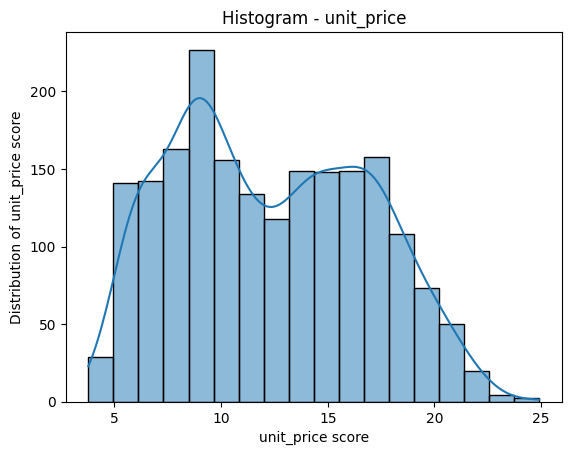

In [15]:
sns.histplot(export['unit_price'],kde = True)
plt.xlabel('unit_price score')
plt.ylabel('Distribution of unit_price score')
plt.title('Histogram - unit_price')
plt.show()

In [16]:
export['unit_price'].median()

11.93

In [17]:
export['unit_price']=export['unit_price'].fillna(export['unit_price'].median())

In [18]:
export.isna().sum()

,0
country,0
product_category,0
quantity,0
unit_price,0
discount_pct,0
total_amount,0
shipping_mode,0
shipping_days,39
payment_terms,29
delayed,0


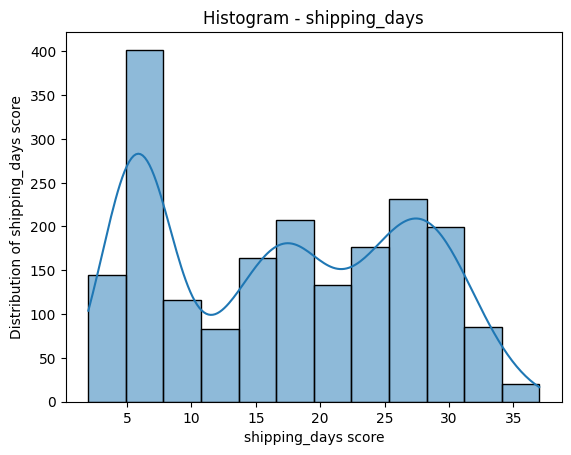

In [19]:
sns.histplot(export['shipping_days'],kde=True)
plt.xlabel('shipping_days score')
plt.ylabel('Distribution of shipping_days score')
plt.title('Histogram - shipping_days')
plt.show()

In [20]:
export['shipping_days'].median()

18.0

In [21]:
export['shipping_days']=export['shipping_days'].fillna(export['shipping_days'].median())

In [22]:
export.isna().sum()

,0
country,0
product_category,0
quantity,0
unit_price,0
discount_pct,0
total_amount,0
shipping_mode,0
shipping_days,0
payment_terms,29
delayed,0


In [23]:
export['payment_terms'].unique()

array(['LC', 'Net30', 'Advance', 'Net60', nan], dtype=object)

In [24]:
export['payment_terms'].value_counts()

,count
payment_terms,
LC,609
Net30,605
Advance,491
Net60,266


In [25]:
export['payment_terms'].mode()[0]

'LC'

In [26]:
export['payment_terms']=export['payment_terms'].fillna(export['payment_terms'].mode()[0])

In [27]:
export.isna().sum()

,0
country,0
product_category,0
quantity,0
unit_price,0
discount_pct,0
total_amount,0
shipping_mode,0
shipping_days,0
payment_terms,0
delayed,0


# handling outliers


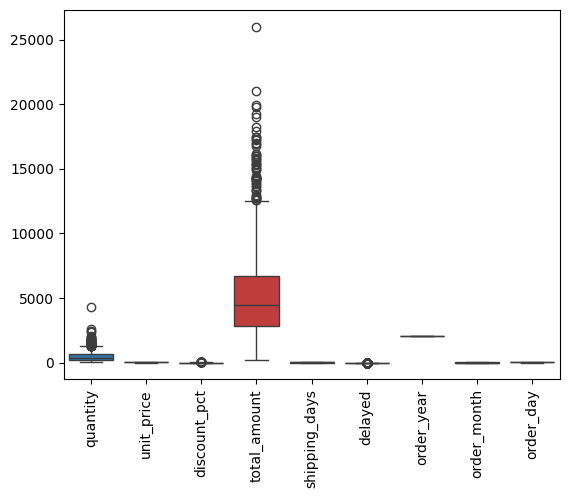

In [28]:
sns.boxplot(export)
plt.xticks(rotation=90)
plt.show()

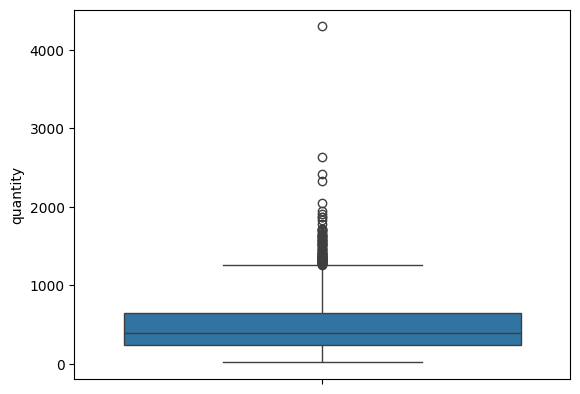

In [29]:
sns.boxplot(export['quantity'])
plt.show()

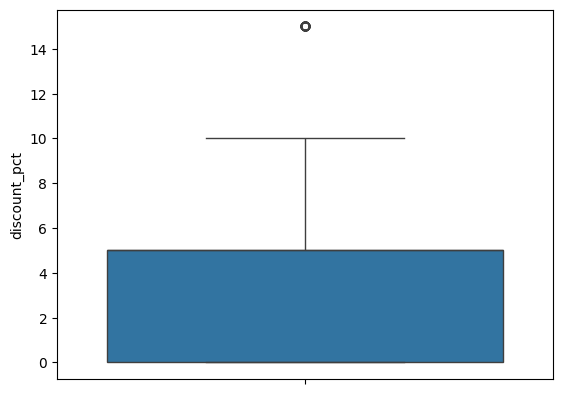

In [30]:
sns.boxplot(export['discount_pct'])
plt.show()

In [31]:
export['quantity'].unique()

array([ 301,  637,  896,  435,  304,  264,  962, 1217,  865, 1091,  903,
        404,  415,  831,  857,  130,  197,  478,  370,  349,  395,  494,
         89,  321, 1427,  497,  689,  331,  883,  710,  270,  868,  343,
        550,  482, 1095,  734,  401,  839,  619,  362,  460,  289,  305,
       2331,  218,  500, 1000,  302,  610,  137,  244,  617,   64,  650,
        357,  795,   55,  624,  191,   93, 1656, 1192,  260,  574,  313,
       1263,  414,  372,  431,  195,   26,  693,  513,  183,  711,  134,
        316,  823,  123,  471,  801,  502,  649,  102,  281, 1151,  654,
       1155,  220,  587,  258, 1314,  135,  691,  874,  995,  437,  230,
        251,  381,  188,  307,  158,  292, 1058,  772,  238,  348,  466,
       1525, 1523,  257,  275,  127,  553,  914,  253,  583,  386,  620,
        578,  247,  533,  452,  451,  374,  776,  804,  139,  162, 1240,
       1055,  222, 1108, 1430,  325,  367,  541,  256,  653, 1718, 1953,
        454,  509,   43,  233,  155, 1117,  205,  5

In [32]:
#outlier count
numeric_cols = export.select_dtypes(include=['int64', 'float64']).columns

# Remove target column
numeric_cols = numeric_cols.drop('delayed')

for col in numeric_cols:
    Q1 = export[col].quantile(0.25)
    Q3 = export[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = ((export[col] < lower_limit) | (export[col] > upper_limit)).sum()

    print(f"{col}: {outlier_count} outliers")

quantity: 85 outliers
unit_price: 0 outliers
discount_pct: 53 outliers
total_amount: 54 outliers
shipping_days: 0 outliers


In [33]:
Q1 = export['quantity'].quantile(0.25)
Q3 = export['quantity'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("Lower limit:", lower)
print("Upper limit:", upper)


Q1: 237.0
Q3: 647.0
Lower limit: -378.0
Upper limit: 1262.0


we keep the outliers as such becoz  these values may represent legitimate high-volume orders. Therefore, they were retained to avoid losing potentially meaningful business information."

# Encoding

In [34]:
export.select_dtypes(include='object').columns

Index(['country', 'product_category', 'shipping_mode', 'payment_terms'], dtype='object')

In [35]:
for col in export.select_dtypes(include='object').columns:
    print("\n", col)
    print(export[col].unique()[:10])


 country
['UAE' 'Saudi Arabia' 'USA' 'UK' 'Singapore' 'Netherlands' 'Germany'
 'Australia']

 product_category
['Spices' 'Coir Products' 'Textiles' 'Tea' 'Rubber Goods' 'Cashew'
 'Seafood']

 shipping_mode
['Sea' 'Air']

 payment_terms
['LC' 'Net30' 'Advance' 'Net60']


In [36]:
categorical_cols = ['country', 'product_category', 'shipping_mode', 'payment_terms']

In [37]:
export = pd.get_dummies(export, columns=categorical_cols, drop_first=True,dtype=int)
export.head()

,quantity,unit_price,discount_pct,total_amount,shipping_days,delayed,order_year,order_month,order_day,country_Germany,...,product_category_Coir Products,product_category_Rubber Goods,product_category_Seafood,product_category_Spices,product_category_Tea,product_category_Textiles,shipping_mode_Sea,payment_terms_LC,payment_terms_Net30,payment_terms_Net60
0,301,17.97,5,5138.52,12.0,0,2025,1,1,0,...,0,0,0,1,0,0,1,1,0,0
1,637,5.80,5,3509.87,17.0,0,2025,1,2,0,...,1,0,0,0,0,0,1,0,1,0
2,896,12.20,0,10931.20,29.0,1,2025,1,2,0,...,0,0,0,0,0,1,1,0,0,0
3,435,8.52,5,3520.89,17.0,0,2025,1,2,0,...,0,0,0,0,1,0,1,0,0,0
4,304,7.57,0,2301.28,29.0,1,2025,1,3,0,...,0,0,0,0,1,0,1,1,0,0


# Scaling

In [38]:
export.select_dtypes(include=['float','int']).columns

Index(['quantity', 'unit_price', 'discount_pct', 'total_amount',
       'shipping_days', 'delayed', 'order_year', 'order_month', 'order_day',
       'country_Germany', 'country_Netherlands', 'country_Saudi Arabia',
       'country_Singapore', 'country_UAE', 'country_UK', 'country_USA',
       'product_category_Coir Products', 'product_category_Rubber Goods',
       'product_category_Seafood', 'product_category_Spices',
       'product_category_Tea', 'product_category_Textiles',
       'shipping_mode_Sea', 'payment_terms_LC', 'payment_terms_Net30',
       'payment_terms_Net60'],
      dtype='object')

In [39]:
scale_cols =['quantity', 'unit_price', 'discount_pct', 'total_amount',
       'shipping_days','order_year', 'order_month', 'order_day']

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
export[scale_cols] = scaler.fit_transform(export[scale_cols])

In [41]:
X = export.drop('delayed', axis=1)
y = export['delayed']

In [42]:
print(X.shape)
print(y.shape)

(2000, 25)
(2000,)


In [43]:
export['delayed'].value_counts()

,count
delayed,
0,1588
1,412


In [44]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2,random_state=42,stratify=y)

# Logistics Regression

In [45]:
#logistics regression model
from sklearn.linear_model import LogisticRegression

In [46]:
lr_model = LogisticRegression(class_weight='balanced',max_iter=1000) #maximum no. of iteration appo ahh warning maarum
lr_model.fit(X_train,y_train)
y_pred_lr_model = lr_model.predict(X_test)

In [47]:
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.metrics import accuracy_score,f1_score
from sklearn.metrics import recall_score

In [48]:
print(confusion_matrix(y_test, y_pred_lr_model))
print('Accuracy is:',accuracy_score(y_test,y_pred_lr_model))
print('Precision is:',precision_score(y_test,y_pred_lr_model))
print('Recall is:',recall_score(y_test,y_pred_lr_model))
print('F1 score is',f1_score(y_test,y_pred_lr_model))

[[191 127]
 [ 18  64]]
Accuracy is: 0.6375
Precision is: 0.33507853403141363
Recall is: 0.7804878048780488
F1 score is 0.46886446886446886


# KNN

In [49]:
#kNN
#Finding the optimum k value
from sklearn.neighbors import KNeighborsClassifier

acc_score = []
for i in range(3,10):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  y_pred_knn = knn.predict(X_test)
  acc = accuracy_score(y_test,y_pred_knn)
  acc_score.append(acc)

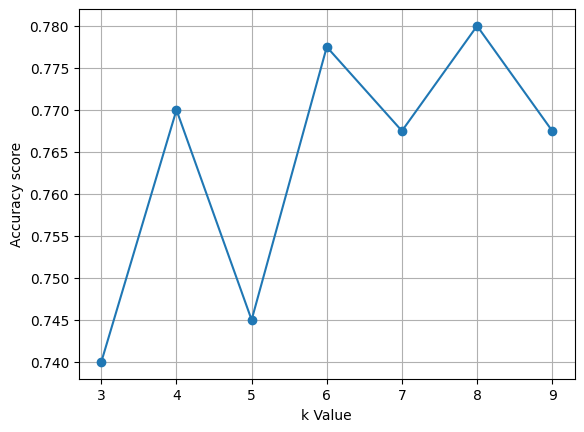

In [50]:
plt.plot(np.arange(3,10),acc_score,'o-')  #o- kodutha becoz points plot avan vendi

plt.xlabel('k Value')
plt.ylabel('Accuracy score')
plt.grid()

In [51]:
#optimum k value is 8 becoz accuracy is high when k =8
#train the knn model for k=8
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)

print(confusion_matrix(y_test, y_pred_lr_model))
print('Accuracy is:',accuracy_score(y_test,y_pred_lr_model))
print('Precision is:',precision_score(y_test,y_pred_lr_model))
print('Recall is:',recall_score(y_test,y_pred_lr_model))
print('F1 score is',f1_score(y_test,y_pred_lr_model))

[[191 127]
 [ 18  64]]
Accuracy is: 0.6375
Precision is: 0.33507853403141363
Recall is: 0.7804878048780488
F1 score is 0.46886446886446886


# SVM

In [52]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [53]:
#linear kernel
svm_linear = SVC(kernel='linear',class_weight='balanced')    #kernel='linear' is a hyperparameter
svm_linear.fit(X_train,y_train)
y_pred_svm_linear = svm_linear.predict(X_test)
print(confusion_matrix(y_test,y_pred_svm_linear))
print(accuracy_score(y_test,y_pred_svm_linear))
print(precision_score(y_test,y_pred_svm_linear))
print(recall_score(y_test,y_pred_svm_linear))
print(f1_score(y_test,y_pred_svm_linear))

[[143 175]
 [ 13  69]]
0.53
0.2827868852459016
0.8414634146341463
0.4233128834355828


In [63]:
#polynomial kernel

svm_poly = SVC(kernel="poly")
svm_poly.fit(X_train,y_train)
y_pred_svm_poly = svm_poly.predict(X_test)
print(confusion_matrix(y_test,y_pred_svm_poly))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_svm_poly))
print("Precision is : ",precision_score(y_test,y_pred_svm_poly))
print("Recall is : ",recall_score(y_test,y_pred_svm_poly))
print("F1 score is : ",f1_score(y_test,y_pred_svm_poly))

[[315   3]
 [ 75   7]]
Accuracy is :  0.805
Precision is :  0.7
Recall is :  0.08536585365853659
F1 score is :  0.15217391304347827


In [64]:
#rbfkernel
svm_rbf=SVC(kernel='rbf',class_weight='balanced')
svm_rbf.fit(X_train,y_train)
y_pred_svm_rbf=svm_rbf.predict(X_test)
print(confusion_matrix(y_test,y_pred_svm_rbf))
print(accuracy_score(y_test,y_pred_svm_rbf))
print(precision_score(y_test,y_pred_svm_rbf))
print(recall_score(y_test,y_pred_svm_rbf))
print(f1_score(y_test,y_pred_svm_rbf))

[[196 122]
 [ 21  61]]
0.6425
0.3333333333333333
0.7439024390243902
0.46037735849056605


# Decision Tree

In [55]:
#decision Trees
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state=42)   #kernel='linear' is a hyperparameter
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)
print(confusion_matrix(y_test,y_pred_dt))
print(accuracy_score(y_test,y_pred_dt))
print(accuracy_score(y_test,y_pred_dt))
print(precision_score(y_test,y_pred_dt))
print(recall_score(y_test,y_pred_dt))
print(f1_score(y_test,y_pred_dt))

[[258  60]
 [ 60  22]]
0.7
0.7
0.2682926829268293
0.2682926829268293
0.2682926829268293


# Random Forest

In [56]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion='entropy',class_weight='balanced',random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
print(confusion_matrix(y_test,y_pred_rf))
print(accuracy_score(y_test,y_pred_rf))
print(accuracy_score(y_test,y_pred_rf))
print(precision_score(y_test,y_pred_rf))
print(recall_score(y_test,y_pred_rf))
print(f1_score(y_test,y_pred_rf))

[[309   9]
 [ 75   7]]
0.79
0.79
0.4375
0.08536585365853659
0.14285714285714285


# adaboost(Adaptive learning)

In [57]:
#Adaboost (Adaptive learning)
from sklearn.ensemble import AdaBoostClassifier

In [58]:
adaboost_clf = AdaBoostClassifier(random_state=42)
adaboost_clf.fit(X_train, y_train)
y_pred_adaboost = adaboost_clf.predict(X_test)
print(confusion_matrix(y_test, y_pred_adaboost))
print('Accuracy', accuracy_score(y_test, y_pred_adaboost))
print('Precision', precision_score(y_test, y_pred_adaboost))
print('recall_score', recall_score(y_test, y_pred_adaboost))
print('f1_score', f1_score(y_test, y_pred_adaboost))

[[317   1]
 [ 80   2]]
Accuracy 0.7975
Precision 0.6666666666666666
recall_score 0.024390243902439025
f1_score 0.047058823529411764


# gradient boost

In [59]:
#gradient boost
from sklearn.ensemble import GradientBoostingClassifier

In [60]:
gradboost_clf = GradientBoostingClassifier(random_state=42)
gradboost_clf.fit(X_train, y_train)
y_pred_gradboost = gradboost_clf.predict(X_test)
print('Accuracy = ', accuracy_score(y_test, y_pred_gradboost))
print('Precision = ', precision_score(y_test, y_pred_gradboost))
print('recall = ', recall_score(y_test, y_pred_gradboost))
print('f1 score = ', f1_score(y_test, y_pred_gradboost))
print(confusion_matrix(y_test, y_pred_gradboost))

Accuracy =  0.81
Precision =  0.65
recall =  0.15853658536585366
f1 score =  0.2549019607843137
[[311   7]
 [ 69  13]]


# XGBoost (Extreme Gradient Boosting)

In [61]:
# XGBoost (Extreme Gradient Boosting)
import xgboost as xgb

In [62]:
xgboost_clf = xgb.XGBClassifier(random_state=42)
xgboost_clf.fit(X_train, y_train)
y_pred_xgboost = xgboost_clf.predict(X_test)
print('Accuracy = ', accuracy_score(y_test, y_pred_xgboost))
print('Precision = ', precision_score(y_test, y_pred_xgboost))
print('recall = ', recall_score(y_test, y_pred_xgboost))
print('f1 score = ', f1_score(y_test, y_pred_xgboost))
print(confusion_matrix(y_test, y_pred_xgboost))

Accuracy =  0.7625
Precision =  0.3617021276595745
recall =  0.2073170731707317
f1 score =  0.26356589147286824
[[288  30]
 [ 65  17]]


After preprocessing and evaluating multiple classification algorithms, I selected the RBF SVM as my final model. Although its accuracy was 64.25%, it achieved the highest recall of 74.39% and F1-score of 46.04%. Since our main objective is to identify delayed orders, recall is particularly important because we want to minimize the number of delayed orders that the model fails to detect.

**RBF SVM** is  the **best overall performance for detecting delayed orders** based on **recall** and **F1-score**.



